<a href="https://colab.research.google.com/github/Tecnologico-de-Monterrey-MNA/nlp-2023-Equipo-4/blob/main/Actividad_en_Equipos_Semanas_9_Modelos_Transformer_para_textos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Actividad en Equipos - Semanas 9: Modelos Transformer para textos en Español e Inglés**


EQUIPO 4

Denisse Maria Ramirez Colmenero - A01561497

Daniela Estévez Rodríguez - A01793723

Ernesto Nicanor Santillán Guerrero - A01793675

José Ovalle Alvarado - A01150742

Genaro Ramos Higuera - A00351269

En la actividad de esta semana trabajarás en equipos mediante el uso de Transformers.
HuggingFace (HF) es una plataforma de una comunidad de IA que promueve las contribuciones de código
abierto, en particular para compartir modelos de aprendizaje profundo, entre ellos los Transformers o modelos
basados en el mecanismo de Attention: https://huggingface.co/.


La plataforma de HF está muy bien documentada, es de acceso abierto, pero deberás generar una cuenta sin
costo para su uso. En ocasiones deberás generar una clave para el uso de algunos modelos, pero es solo para el
control del uso de dicha plataforma y no generan algún costo para su uso educativo o de investigación, al
menos hasta ahora.
En particular en esta actividad estarás usando varios de los modelos Transformer que hacen tareas diversas,
tanto en inglés como en español. El objetivo es que te familiarices con dicha plataforma y experimentes
posteriormente con ella para las tareas o problemáticas particulares que te interesen.

1. Descarga el archivo amazonbaby5000.csv que se encuentra en Canvas. Este archivo está formado
de comentarios en inglés sobre productos para bebé adquiridos en la plataforma de Amazon.

In [ ]:
#Instalamos libreria con pip y comentamos (desactivamos comando)

# !pip install transformers datasets evaluate
# !apt-get install git-lfs
# !pip install git+https://github.com/huggingface/accelerate
# !pip install xformers
# !pip install sacremoses
# !pip install sentencepiece
# !pip install pysentimiento
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# solo activar si se quiere grabar info a huggigface
# from huggingface_hub import notebook_login
# notebook_login()

In [ ]:
# importat torch y verificar gpu este activo
import torch
print(torch.cuda.is_available())
print(torch.cuda.current_device())

True
0


In [ ]:
# importar librerías
import pandas as pd
import numpy  as np
import os
import accelerate
pd.set_option('max_colwidth', 800)
pd.set_option('display.max_rows',100)
os.listdir('/kaggle/input/amazon-baby')

['amazonbaby5000.csv']

In [ ]:
am_df = pd.read_csv('/kaggle/input/amazon-baby/amazonbaby5000.csv')
am_df.rename(columns = {'review':'text', 'rating':'labels'}, inplace = True)

In [ ]:
am_df.head()

,text,labels
0,I think it is more Expensive than drugstore that only cost 27usd.so you have a good chose if you want to but it,0
1,"When I saw this on Amazon, I put it into my wish list so I would be able to find it again. I knew it would be the next baby gift I would purchase. The opportunity recently came up and as soon as I read the shower invitstion, I placed my order. This looks so comfortable. I love that it has a second cover that allows it to grow with the child. So many items designed for a baby are only used for such a short time, but this should be able to be used for much longer. I have given this to the mother-to-be and she was thrilled to receive it. The 7 year old had to try it out, already making plans on how she and the new baby can share it to watch TV! There is a strsp on the bottom that makes moving it from room to room easy. The cover zips off, to change to the other one, or to wash it...",1
2,"We really like these valances. They have such cute characters on them. We highly recommend them! The only downfall is having to iron them after they come out of the dryer, but it's worth it!",1
3,No light emits from the night light. They painted it a solid color and didnt leave an opening in the back. You will end up returning it.,0
4,"I was really hoping for this to be a conventient travel wipe dispenser, but it just didn't for for me. It doesn't close all the way. So it dries out the wipes =/",0


2. Realiza una partición de los datos en el porcentaje que consideres adecuado, entrenamiento,
validación y prueba.

In [ ]:
X = am_df.text
Y = am_df.labels

print('Review_Examples\n')
print(X.head())

print('\n')
print('Label_Examples\n')
print(Y.head())

Review_Examples

0    I think it is more Expensive than drugstore th...
1    When I saw this on Amazon, I put it into my wi...
2    We really like these valances.  They have such...
3    No light emits from the night light. They pain...
4    I was really hoping for this to be a conventie...
Name: text, dtype: object


Label_Examples

0    0
1    1
2    1
3    0
4    0
Name: labels, dtype: int64


In [ ]:
# Describimos los datos (min,max,etc.) de longitud de enuciados
X.apply(len).describe()

count    5000.000000
mean      440.080000
std       460.829402
min         7.000000
25%       163.000000
50%       291.500000
75%       541.000000
max      5783.000000
Name: text, dtype: float64

In [ ]:
# particionamos con sklearn
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(X, Y, train_size = .70, shuffle = True, random_state = 1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size = .50, shuffle = True, random_state = 17)

print('X,y Train:', len(x_train), len(y_train))
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))


X,y Train: 3500 3500
X,y Val: 750 750
X,y Test 750 750


In [ ]:
# concat df's to later build hf datasets

train_data = pd.concat([x_train, y_train], axis=1)
val_data  = pd.concat([x_val  , y_val], axis=1)
test_data   = pd.concat([x_test , y_test], axis=1)


# Hugging Face Dataset
from datasets import Dataset

# convert train, val and test to huggingface datasets


hg_train_data = Dataset.from_pandas(train_data)
hg_val_data   = Dataset.from_pandas(val_data)
hg_test_data  = Dataset.from_pandas(test_data)
hg_all_data   = Dataset.from_pandas(am_df)


### Some examples of the hf dataset for both, rating and review

In [ ]:
# lenght of each hf dataset

print(f'The length of hg_train_data is {len(hg_train_data)}.\n')
print(f'The length of hg_val_data is {len(hg_val_data)}.\n')
print(f'The length of hg_test_data is {len(hg_test_data)}.\n')
print(f'The length of hg_all_data is {len(hg_all_data)}.\n')


The length of hg_train_data is 3500.

The length of hg_train_data is 750.

The length of hg_train_data is 750.

The length of hg_train_data is 5000.



The length of hg_train_data is 3500.

The length of hg_val_data is 750.

The length of hg_test_data is 750.

The length of hg_all_data is 5000.

3. Utiliza un modelo Transformer de HuggingFace para análisis de sentimiento en inglés y lleva a cabo:
la predicción de los comentarios en los siguientes casos:



*  a. Utilizando un modelo predeterminado de HF de manera directa, es decir, sin ajuste de
parámetros del modelo. Indicar el desempeño (accuracy) obtenido.





In [ ]:
from transformers import set_seed
set_seed(42)
model_name="distilbert-base-uncased-finetuned-sst-2-english"
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# build preprocess function for reviews
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

In [ ]:
tokenized_train = hg_train_data.map(preprocess_function, batched=True)
tokenized_val   = hg_val_data.map(preprocess_function, batched=True)
tokenized_test  = hg_test_data.map(preprocess_function, batched=True)
tokenized_all   = hg_all_data.map(preprocess_function, batched=True)

  0%|          | 0/4 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/5 [00:00<?, ?ba/s]

In [ ]:
from transformers import pipeline

In [ ]:
sentiment_pipe = pipeline(
                'sentiment-analysis',
                 model = model_name,
                 # tokenizer = model_name,
                 # top_k = None,
                 truncation = True,
                 device=0
)

In [ ]:
tokens_train = []

for token in tokenized_train["text"]:
  tokens_train.append(token)

tokens_val = []

for token in tokenized_val["text"]:
  tokens_val.append(token)

tokens_test = []

for token in tokenized_test["text"]:
  tokens_test.append(token)


tokens_all = []

for token in tokenized_all["text"]:
  tokens_all.append(token)

In [ ]:
tokens_train[0]

"When I had my first child my employer didn't have a private place for me to pump.  Since I refused to pump in the bathroom as everytime the toilet is flushed it sends bacteria and feces into the air, my only option was a battery operated pump.  I bought it at BRU, and besides the noise and millions of batteries I went through it was okay.  I didn't however pull enough of the milk out of my breast and I started to develop mastitis in both.  I only recommend this item if you have no option buy to use battery operated devises, other wise, spend the money to buy a nice one, you'll send it eventually in batteries anyway."

In [ ]:
# example
sentiment_pipe(tokens_train[0])[0]["label"] #run pipe then acces list then acess label

'NEGATIVE'

In [ ]:
# another example
x = sentiment_pipe(tokens_train[0:4])
x

[{'label': 'NEGATIVE', 'score': 0.7732192277908325},
 {'label': 'NEGATIVE', 'score': 0.996496856212616},
 {'label': 'POSITIVE', 'score': 0.9570292234420776},
 {'label': 'POSITIVE', 'score': 0.9876370429992676}]

In [ ]:
# get sentiments from pipeline
sentiment_train = sentiment_pipe(tokens_train) #
sentiment_val   = sentiment_pipe(tokens_val) #
sentiment_test  = sentiment_pipe(tokens_test) #

In [ ]:
# get predictions from semtiments pipeline
train_pred = []

for n in range(0,len(sentiment_train)):
  train_pred.append(sentiment_train[n]["label"])

val_pred = []

for n in range(0,len(sentiment_val)):
  val_pred.append(sentiment_val[n]["label"])

test_pred = []

for n in range(0,len(sentiment_test)):
  test_pred.append(sentiment_test[n]["label"])


In [ ]:
# replace negative and positive labels with 1 and 0s
def replace_labels(prediction_list):
  replaced_list = []

  for prediction in prediction_list:
    if prediction == "NEGATIVE":
      replaced_list.append(0)
    else:
      replaced_list.append(1)
  return replaced_list


In [ ]:
pred_train = replace_labels(train_pred)
pred_val   = replace_labels(val_pred)
pred_test  = replace_labels(test_pred)

In [ ]:
# create dataframes for train, val, test

train_df = pd.DataFrame(list(zip(tokenized_train["text"],tokenized_train["labels"],pred_train)), columns = ["text", "act_label", "pred_label"])
val_df   = pd.DataFrame(list(zip(tokenized_val["text"],tokenized_val["labels"],pred_val)), columns = ["text", "act_label", "pred_label"])
test_df  = pd.DataFrame(list(zip(tokenized_test["text"],tokenized_test["labels"],pred_test)), columns = ["text", "act_label", "pred_label"])

# check if predicted and actuals are equal

train_df['correct_pred'] = (train_df['act_label'] == train_df['pred_label']).astype(int)
val_df['correct_pred']   = (val_df['act_label']   == val_df['pred_label']).astype(int)
test_df['correct_pred']  = (test_df['act_label']  == test_df['pred_label']).astype(int)

train_df.head()

,text,act_label,pred_label,correct_pred
0,"When I had my first child my employer didn't have a private place for me to pump. Since I refused to pump in the bathroom as everytime the toilet is flushed it sends bacteria and feces into the air, my only option was a battery operated pump. I bought it at BRU, and besides the noise and millions of batteries I went through it was okay. I didn't however pull enough of the milk out of my breast and I started to develop mastitis in both. I only recommend this item if you have no option buy to use battery operated devises, other wise, spend the money to buy a nice one, you'll send it eventually in batteries anyway.",0,0,1
1,"Okay, so I had an aspirator that I thought was bad so my husband and I bought this one.....and it doesn't work at all! I wanted this one because the tip was smaller for my young baby's nose....but the thing doesn't suck anything out. My poor baby can't breathe : (",0,0,1
2,"This swing was a lifesaver for our household!The swing can be turned to rock forward & back,or side to side; so if the baby gets restless,you can offer them a completly different view with the push of a button.The little globe on top changes color as it turns,which proved to be facinating to my son.My son was born with severe acid reflux,and was unable to lay completly flat,especially after eating,so this swing also served as a cradle/bassinet for the first few months of his life.We both slept much sounder due to the aqurium swing and the soothing water sounds it makes(as sound as you can sleep with a newborn.)Although there is a slight mechanical sound as well,its not too bad.Last,I do recall that when we first got home,the swing seemed to go a little fast for an infant-we simply laye...",1,1,1
3,"Right out of the package, the Skip Hop Forma Pack & Go Diaper Tote Bag is beautiful. The peacock color is so attractive without screaming, ""BABY BAG!"" The bag is large enough to pack enough diapers, supplies and clothing for a weekend with the grandparents. The pockets are plentiful and well-placed. I am disappointed that there is no shoulder strap option. The tote straps are basically long enough to carry the bag on your shoulder, but it isn't really comfortable ... especially when the bag is well-stocked. I also don't understand why the stroller shuttle clips are attached to the interior lining of the bag. I actually don't feel secure attaching the well-stocked bag to the stroller because I feel as if the fabric is going to rip where it attaches. I also found it troublesome t...",1,1,1
4,"After spending a lot of time looking for a crib for our first child, I finally decided to roll the dice and get this one without seeing it in person. It looks pretty identical to the Pottery Barn Kids Kendall crib, but for about half the price.It shipped sooner than expected and was very easy to assemble. We did notice a slight odor as other reviews have mentioned, but the smell seemed to be coming from the packaging rather than the crib itself. We bought it well in advance of our baby's arrival, so we just left the window open over night and it was no big deal.The main reason I bought this crib was for its height. My husband and I are both tall and I was concerned about having to bend really far with a shorter crib. Just be aware that the height is measured at the highest point (the h...",1,0,0


In [ ]:
# calculate accuracy for each dataset(train, validation, test)

acc_train = train_df.correct_pred.sum() / len(train_df)
acc_val   = val_df.correct_pred.sum() / len(val_df)
acc_test  = test_df.correct_pred.sum() / len(test_df)

print(f'El ACCURACY para ENTRENAMIENTO con el preentrenamiento es de {round(acc_train*100,2)}%')
print(f'El ACCURACY para VALIDACIÓN con el preentrenamiento es de {round(acc_val*100,2)}%')
print(f'El ACCURACY para PRUEBA con el preentrenamiento es de {round(acc_test*100,2)}%')

El ACCURACY para ENTRENAMIENTO con el preentrenamiento es de 82.86%
El ACCURACY para VALIDACIÓN con el preentrenamiento es de 82.4%
El ACCURACY para PRUEBA con el preentrenamiento es de 79.33%


* b. Utiliza ahora un ajuste de parámetros (fine-tuning) con el modelo Transformer DistilBERT,
para generar un nuevo modelo y clasificación de los comentarios. Es decir, el objetivo es
utilizar un modelo Transformer pre-entrenado y adaptarlo (fine-tuning) o ajustarlo a las
características de tus datos de entrenamiento. Indicar desempeño (accuracy) obtenido.



In [ ]:
from transformers import AutoTokenizer
model_name="distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.model_max_length = 400

In [ ]:
# padding
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# model Creation and training

# import libraries

from transformers import AutoModelForSequenceClassification
import numpy as np
from datasets import load_metric

# model creation from class
set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


# compute_mtrics function to evaluate models performance

def compute_metrics(eval_pred):
   load_accuracy = load_metric("accuracy")
   load_f1 = load_metric("f1")

   logits, labels = eval_pred
   predictions = np.argmax(logits, axis=-1)
   accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
   f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
   return {"accuracy": accuracy, "f1": f1}

In [ ]:
# training
from transformers import TrainingArguments, Trainer
repo_name = "finetuning-sentiment-model"
training_args = TrainingArguments(
   output_dir=repo_name,
   learning_rate=2e-5,
   per_device_train_batch_size=16,
   per_device_eval_batch_size=16,
   num_train_epochs=2,
   weight_decay=0.01,
   save_strategy="epoch",
   push_to_hub=False,
)

trainer = Trainer(
   model=model,
   args=training_args,
   train_dataset=tokenized_train, #here is the input for the train dataset
   eval_dataset=tokenized_val, # here is the input for the evaluation data set (val / test)
   tokenizer=tokenizer,
   data_collator=data_collator,
   compute_metrics=compute_metrics,
)

In [ ]:
# Comando axuliar para limpiar cache cuda
#torch.cuda.empty_cache()

In [ ]:
# results training
trainer.train()

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


TrainOutput(global_step=220, training_loss=0.22573559500954368, metrics={'train_runtime': 201.0744, 'train_samples_per_second': 34.813, 'train_steps_per_second': 1.094, 'total_flos': 733429555394640.0, 'train_loss': 0.22573559500954368, 'epoch': 2.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.26817265152931213,
 'eval_accuracy': 0.9066666666666666,
 'eval_f1': 0.9384885764499121,
 'eval_runtime': 6.5076,
 'eval_samples_per_second': 115.25,
 'eval_steps_per_second': 3.688,
 'epoch': 2.0}

* c. Compara los resultados e incluye tus comentarios.
NOTA: Puedes apoyarte en el siguiente tutorial de la misma comunidad de HF:
https://huggingface.co/blog/sentiment-analysis-python



In [ ]:
test_pred=trainer.predict(tokenized_test)

In [ ]:
# Metricos obtenidos en test data
test_pred.metrics

{'test_loss': 0.32001951336860657,
 'test_accuracy': 0.876,
 'test_f1': 0.9184925503943908,
 'test_runtime': 6.1267,
 'test_samples_per_second': 122.416,
 'test_steps_per_second': 3.917}

In [ ]:
test_df['tuned_pred_en']=np.argmax(test_pred.predictions,axis=1)

In [ ]:
test_df['tuned_correct_pred_en']  = (test_df['act_label']  == test_df['tuned_pred_en']).astype(int)

In [ ]:
test_df

,text,act_label,pred_label,correct_pred,texto_esp,tuned_pred_es,tuned_correct_pred_es,tuned_pred,tuned_correct_pred,tuned_pred_en,tuned_correct_pred_en
0,I like it a lot but I hate the fact it doesn't come with a mobile like the other pack and plays ! If there's anyway I can purchase it separately let me know so I can buy it asap ! Great product but it should have that extra part,0,1,0,"Me gusta mucho, pero odio el hecho de que no viene con un móvil como el otro pack y juega ! Si hay de todos modos puedo comprar por separado hágamelo saber para que pueda comprar lo antes posible ! Gran producto, pero debe tener esa parte adicional",1,0,1,0,1,0
1,"Fits great for the space we need. It was not easy lokin g for one at local stores, byt Amazon had it.",1,0,0,"Encaja muy bien para el espacio que necesitamos. No era fácil lokin g para uno en las tiendas locales, Byt Amazon lo tenía.",1,1,1,1,1,1
2,"This is a great high chair, we love it - how it looks, how it works, how customizable it is, everything. With this chair,baby can be at the table with us, which is perfect since we want to emphasize the social and family parts of mealtimes together over the food itself (food before one is just for fun).My only complaint would be that you have to half take it apart to reconfigure it (seat depth, level for footrest), but since that's not something that's done very often, it's not a big deal.You don't really need any of the available accessories: the cushions are just going to get dirty, though a case might be made for them if you're having baby join you at the table before he starts on solids; the tray is unnecessary, since the biggest selling point of this chair (for me at least) is the...",1,0,0,"Esta es una gran silla alta, nos encanta - cómo se ve, cómo funciona, lo personalizable que es, todo. Con esta silla, bebé puede estar en la mesa con nosotros, que es perfecto ya que queremos enfatizar las partes sociales y familiares de las comidas juntas sobre la comida en sí mismo (la comida antes de uno es sólo por diversión).Mi única queja sería que usted tiene que la mitad tomarlo aparte para reconfigurarlo (profundidad del asiento, nivel para reposapiés), pero ya que eso no es algo que se hace muy a menudo, no es una gran cosa.Usted realmente no necesita cualquiera de los accesorios disponibles: los cojines sólo van a ensuciarse, aunque un caso se puede hacer para ellos si usted va a tener bebé unirse a la mesa antes de que él comience en sólidos; la bandeja es innecesario, ya q...",1,1,0,0,0,0
3,"I thought this was the cutest thing when our 4 month old daughter got it as a present. Now at nearly 5 months, she loves it and enjoys chewing on it... and that's where the danger lies. The antlers are not quite big enough to be safe. Our daughter managed to wedge the end of the antler into her mouth, and due to the jagged shape, couldn't get it out. She started to gag on it and couldn't get it out of her mouth. Her face turned all red and her eyes were watering. Luckily her mom and I were right at hand and were able to pull it out of her mouth, but we definitely won't be letting her play with it without very close supervision.Parents of toddlers and young babies, please be aware of the danger. Because of the shape, I am pretty sure her air passage was not cut off, but it was st...",0,0,1,"Pensé que esto era lo más lindo cuando nuestra hija de 4 meses lo recibió como regalo. Ahora, a casi 5 meses, le encanta y disfruta masticarlo... y ahí es donde está el peligro. Las cornamentas no son lo suficientemente grandes como para estar a salvo. Nuestra hija logró meter el extremo de la cornamenta en su boca, y debido a la forma irregular, no pudo sacarlo. Ella comenzó a amordazarla y no pudo sacarla de su boca. Su cara se volvió toda roja y sus ojos estaban regando. Afortunadamente su madre y yo estábamos a mano y pudimos sacarla de su boca, pero definitivamente no la dejaremos jugar con ella sin una supervisión muy estrecha. Padres de niños pequeños y b

##COMENTARIOS


El Accuracy del modelo "directo" para el caso de datos de TEST fue de 79.33% pero después de entrenar el modelo con los datos de amazonbaby, se puede observar que el accuracy aumento a 90.67%.




4. Utiliza el modelo Transformer pre-entrenado para diferentes idiomas llamado Helsinki-NLP de HF,
para hacer una traducción del Inglés al Español de los 5000 comentarios. Observa algunos de los
comentarios traducidos y comenta qué tan bien consideras dichas traducciones. Por el momento es
un simple comentario subjetivo, aunque existen métricas y bases de datos para evaluar el
desempeño de un Trasnformer.
NOTA: Guarda el archivo de los comentarios traducidos para facilitar su uso en las siguientes
preguntas de esta actividad.
Existen pocos modelos pre-entrenados con corpus en Español, pero dos de los más conocidos son
BETO ( https://github.com/dccuchile/beto ) y MarIA ( https://arxiv.org/abs/2107.07253 ). En
particular para análisis de sentimiento se puede utilizar alguno de los modelos derivados de BETO:

In [ ]:
from transformers import AutoModelForSeq2SeqLM
import sentencepiece

In [ ]:
set_seed(42)
model_name_t='Helsinki-NLP/opus-mt-en-es'
model = AutoModelForSeq2SeqLM.from_pretrained(model_name_t)

In [ ]:
# Tokenizar
tokenizer_t = AutoTokenizer.from_pretrained(model_name_t)
tokenizer_t.model_max_length = 512


In [ ]:
tokenizer_t

MarianTokenizer(name_or_path='Helsinki-NLP/opus-mt-en-es', vocab_size=65001, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=True)

In [ ]:
translation_pipe = pipeline('translation',model = model_name_t,truncation = True,device=0)


In [ ]:
translation_pipe('how are you?')

[{'translation_text': '¿Cómo estás?'}]

In [ ]:
#Create hg_all_data1 from train,test,val

combined_df=pd.concat([train_data,val_data,test_data],axis=0)
hg_all_data_1=Dataset.from_pandas(combined_df)

# build preprocess function for reviews

tokenized_all_t   = hg_all_data_1.map(lambda data: tokenizer_t(data["text"],truncation=True,max_length=512,padding=True), batched=True)

  0%|          | 0/5 [00:00<?, ?ba/s]

In [ ]:
tokenized_all_t

Dataset({
    features: ['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 5000
})

In [ ]:
tokens_english = []

for token in tokenized_all_t["text"]:
  tokens_english.append(token)


In [ ]:
tokens_english[0]

"When I had my first child my employer didn't have a private place for me to pump.  Since I refused to pump in the bathroom as everytime the toilet is flushed it sends bacteria and feces into the air, my only option was a battery operated pump.  I bought it at BRU, and besides the noise and millions of batteries I went through it was okay.  I didn't however pull enough of the milk out of my breast and I started to develop mastitis in both.  I only recommend this item if you have no option buy to use battery operated devises, other wise, spend the money to buy a nice one, you'll send it eventually in batteries anyway."

In [ ]:
# traducimos 2 lineas del texto
translation_pipe(tokens_english[0:2])

[{'translation_text': 'Cuando tuve a mi primer hijo mi empleador no tenía un lugar privado para bombear. Ya que me negué a bombear en el baño ya que cada vez que el inodoro se descarga que envía bacterias y heces en el aire, mi única opción era una bomba operada por la batería. Lo compré en BRU, y además del ruido y millones de baterías que pasé a través de él estaba bien. Sin embargo, no saqué suficiente de la leche de mi pecho y empecé a desarrollar mastitis en ambos. Sólo recomiendo este artículo si no tiene opción de comprar para utilizar dispositivos operados por la batería, otro sabio, gastar el dinero para comprar una buena, usted lo enviará eventualmente en baterías de todos modos.'},
 {'translation_text': 'Vale, así que tenía un aspirador que pensé que era malo, así que mi marido y yo compramos este... ¡y no funciona en absoluto! Quería este porque la punta era más pequeña para la nariz de mi bebé... pero la cosa no chupa nada. Mi pobre bebé no puede respirar : ('}]

In [ ]:
# traducimos todos los enuciados
translation_results = translation_pipe(tokens_english,batch_size=32)

Your input_length: 463 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 475 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 485 is bigger than 0.9 * max_length: 512. You

In [ ]:
# Comparamos unos textos
print(tokens_english[2])
print('\n')
print(translation_results[2]['translation_text'])


This swing was a lifesaver for our household!The swing can be turned to rock forward & back,or side to side; so if the baby gets restless,you can offer them a completly different view with the push of a button.The little globe on top changes color as it turns,which proved to be facinating to my son.My son was born with severe acid reflux,and was unable to lay completly flat,especially after eating,so this swing also served as a cradle/bassinet for the first few months of his life.We both slept much sounder due to the aqurium swing and the soothing water sounds it makes(as sound as you can sleep with a newborn.)Although there is a slight mechanical sound as well,its not too bad.Last,I do recall that when we first got home,the swing seemed to go a little fast for an infant-we simply layed a rolled up recieving blanket over the blue swinging arm to weigh it down a bit,and it was perfect!


¡Este columpio era un salvavidas para nuestra casa!El columpio se puede girar hacia adelante y hacia

In [ ]:
# Comparamos unos textos
print(tokens_english[100])
print('\n')
print(translation_results[100]['translation_text'])


If you don't know what you're having, I highly recommend this collection.  We're not finding out what were having this time around (we have 2 boys) and found this collection at Babies R Us when I was picking up some other items (didn't even know Babies R Us had bedding of this caliber).  The soft yellows and greens are perfect.  I'm a little concerned about the blue (in case we have a girl) but love this set so much that we're going to get it anyways.  If we do have a girl, I'll just put in some pink stuffed animals and other accessories.


Si usted no sabe lo que está teniendo, recomiendo encarecidamente esta colección. No estamos descubriendo lo que estaba teniendo esta vez (tenemos 2 niños) y encontramos esta colección en Babies R Us cuando estaba recogiendo algunos otros artículos (ni siquiera sabía que Babies R Us tenía ropa de cama de este calibre). Los amarillos suaves y verdes son perfectos. Estoy un poco preocupado por el azul (en caso de que tengamos una chica) pero me encant

##COMENTARIOS

En general consideramos que la traducción es buena.
Observamos también en algunos casos que la traducción de unos verbos no eran exactamente correcto, creemos que era debido a que las demás palabras en la oración no tenían mucha relación con ese verbo y por eso no podía identificar bien por cual palabra al español traducirla.

También observamos que había palabras que no se utilizan diariamente en países de latinoamerica, sin embargo se logra entender perfectamente el enunciado. El significado general es correcto.


5. Utiliza el modelo Transformer “pysentimiento”, basado en BETO y este a su vez basado en BERT,
para llevar a cabo un análisis de sentimiento (sentiment analysis) y hacer la predicción de los
comentarios traducidos al español. Incluye tus comentarios del resultado obtenido.

In [ ]:
# Metodo 1 : Usando analizador
from pysentimiento import create_analyzer
analyzer = create_analyzer(task="sentiment", lang="es")

In [ ]:
# Extraemos los textos traducidos al espanol
textos=[x[1]['translation_text'] for x in enumerate(translation_results)]

In [ ]:
# observamos algunos de los textos extraidos
textos[0:2]

['Cuando tuve a mi primer hijo mi empleador no tenía un lugar privado para bombear. Ya que me negué a bombear en el baño ya que cada vez que el inodoro se descarga que envía bacterias y heces en el aire, mi única opción era una bomba operada por la batería. Lo compré en BRU, y además del ruido y millones de baterías que pasé a través de él estaba bien. Sin embargo, no saqué suficiente de la leche de mi pecho y empecé a desarrollar mastitis en ambos. Sólo recomiendo este artículo si no tiene opción de comprar para utilizar dispositivos operados por la batería, otro sabio, gastar el dinero para comprar una buena, usted lo enviará eventualmente en baterías de todos modos.',
 'Vale, así que tenía un aspirador que pensé que era malo, así que mi marido y yo compramos este... ¡y no funciona en absoluto! Quería este porque la punta era más pequeña para la nariz de mi bebé... pero la cosa no chupa nada. Mi pobre bebé no puede respirar : (']

In [ ]:
# analizar sentimientos observados en los textos
res=[analyzer.predict(text) for text in textos]

In [ ]:
# ver algunos de los resultados
res[0:10]

[AnalyzerOutput(output=NEG, probas={NEG: 0.584, NEU: 0.396, POS: 0.019}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.968, NEU: 0.030, POS: 0.002}),
 AnalyzerOutput(output=NEU, probas={NEU: 0.735, POS: 0.216, NEG: 0.049}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.896, NEU: 0.097, POS: 0.007}),
 AnalyzerOutput(output=POS, probas={POS: 0.586, NEU: 0.399, NEG: 0.015}),
 AnalyzerOutput(output=POS, probas={POS: 0.969, NEU: 0.029, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.836, NEU: 0.157, NEG: 0.007}),
 AnalyzerOutput(output=NEU, probas={NEU: 0.759, NEG: 0.182, POS: 0.059}),
 AnalyzerOutput(output=POS, probas={POS: 0.870, NEU: 0.124, NEG: 0.006}),
 AnalyzerOutput(output=NEU, probas={NEU: 0.607, POS: 0.382, NEG: 0.011})]

##COMENTARIOS

Observando el análisis de sentimiento para el caso de los enunciados en español podemos notar que el modelo batalla un poco más en identificar si el comentario es positivo o negativo. Las probabilidades que arroja el modelo tiene un accuracy más bajo que en el modelo en inglés. Para los modelos en inglés pudimos notar que su desempeño era mejor y su precisión siempre estaba arriba del 90%.
Posiblemente la diferencia en el desempeño se debe a la perdida de información durante la traducción que se hizo anteriormente.

6. Resume los resultados obtenidos en esta actividad de manera tabular e incluye tus comentarios
finales.

NOTA: A partir de esta actividad, no dudes en experimentar con otros modelos Transformer preentrenados
tanto para traducción al español, como para análisis de sentimiento.

In [ ]:
sentimientos=[item.output for item in res]

In [ ]:
len(sentimientos)

5000

In [ ]:
def replace_labels_1(prediction_list):
    replaced_list = []

    for prediction in prediction_list:
        if prediction == "NEG":
            replaced_list.append(0)
        elif prediction == "POS":
            replaced_list.append(1)
        else:
            replaced_list.append(2)
    return replaced_list


In [ ]:
sent=replace_labels_1(sentimientos)

In [ ]:
ambos_resultados=pd.concat([train_df,val_df,test_df],axis=0)

In [ ]:
train_df.columns

Index(['text', 'act_label', 'pred_label', 'correct_pred'], dtype='object')

In [ ]:
ambos_resultados['espanol']=textos

In [ ]:
ambos_resultados['pred_label_1']=sent

In [ ]:
ambos_resultados['correct_pred_1'] = (ambos_resultados['act_label'] == ambos_resultados['pred_label_1']).astype(int)

In [ ]:
ambos_resultados


,text,act_label,pred_label,correct_pred,espanol,pred_label_1,correct_pred_1
0,"When I had my first child my employer didn't have a private place for me to pump. Since I refused to pump in the bathroom as everytime the toilet is flushed it sends bacteria and feces into the air, my only option was a battery operated pump. I bought it at BRU, and besides the noise and millions of batteries I went through it was okay. I didn't however pull enough of the milk out of my breast and I started to develop mastitis in both. I only recommend this item if you have no option buy to use battery operated devises, other wise, spend the money to buy a nice one, you'll send it eventually in batteries anyway.",0,0,1,"Cuando tuve a mi primer hijo mi empleador no tenía un lugar privado para bombear. Ya que me negué a bombear en el baño ya que cada vez que el inodoro se descarga que envía bacterias y heces en el aire, mi única opción era una bomba operada por la batería. Lo compré en BRU, y además del ruido y millones de baterías que pasé a través de él estaba bien. Sin embargo, no saqué suficiente de la leche de mi pecho y empecé a desarrollar mastitis en ambos. Sólo recomiendo este artículo si no tiene opción de comprar para utilizar dispositivos operados por la batería, otro sabio, gastar el dinero para comprar una buena, usted lo enviará eventualmente en baterías de todos modos.",0,1
1,"Okay, so I had an aspirator that I thought was bad so my husband and I bought this one.....and it doesn't work at all! I wanted this one because the tip was smaller for my young baby's nose....but the thing doesn't suck anything out. My poor baby can't breathe : (",0,0,1,"Vale, así que tenía un aspirador que pensé que era malo, así que mi marido y yo compramos este... ¡y no funciona en absoluto! Quería este porque la punta era más pequeña para la nariz de mi bebé... pero la cosa no chupa nada. Mi pobre bebé no puede respirar : (",0,1
2,"This swing was a lifesaver for our household!The swing can be turned to rock forward & back,or side to side; so if the baby gets restless,you can offer them a completly different view with the push of a button.The little globe on top changes color as it turns,which proved to be facinating to my son.My son was born with severe acid reflux,and was unable to lay completly flat,especially after eating,so this swing also served as a cradle/bassinet for the first few months of his life.We both slept much sounder due to the aqurium swing and the soothing water sounds it makes(as sound as you can sleep with a newborn.)Although there is a slight mechanical sound as well,its not too bad.Last,I do recall that when we first got home,the swing seemed to go a little fast for an infant-we simply laye...",1,1,1,"¡Este columpio era un salvavidas para nuestra casa!El columpio se puede girar hacia adelante y hacia atrás, o de lado a lado; así que si el bebé se inquieta, usted puede ofrecerles una vista completamente diferente con el pulsar de un botón.El pequeño globo en la parte superior cambia de color a medida que gira, lo que resultó ser facinante para mi hijo.Mi hijo nació con reflujo ácido severo, y no pudo tumbarse completamente plano, especialmente después de comer, así que este columpio también sirvió como cuna/bassina para los primeros meses de su vida.Ambos dormimos mucho más sonoro debido al columpio del aqurio y los sonidos del agua calmante que hace (como sonido como se puede dormir con un recién nacido).Aunque hay un ligero sonido mecánico también, no es demasiado malo.Por último, ...",2,0
3,"Right out of the package, the Skip Hop Forma Pack & Go Diaper Tote Bag is beautiful. The peacock color is so attractive without screaming, ""BABY BAG!"" The bag is large enough to pack enough diapers, supplies and clothing for a weekend with the grandparents. The pockets are plentiful and well-placed. I am disappointed that there is no shoulder strap option. The tote straps are basically long enough to carry the bag on your shoulder, but it isn't

In [ ]:
# calculate accuracy for english sentiment (pretrained) and translated

acc_ingles = ambos_resultados.correct_pred.sum() / len(ambos_resultados)
acc_espanol   = ambos_resultados.correct_pred_1.sum() / len(ambos_resultados)


print(f'El ACCURACY en Ingles {round(acc_ingles*100,2)}%')
print(f'El ACCURACY para Espanol {round(acc_espanol*100,2)}%')


El ACCURACY en Ingles 82.26%
El ACCURACY para Espanol 70.62%


In [ ]:
# Metodo 2 : Usando finetuner en modelo pysentimiento/robertuito-base-uncased

In [ ]:
# Generamos train,val y test para datos traducidos, manteniendo el mismo split que el original en ingles
train_data_e=ambos_resultados[0:3500][['espanol','act_label']]
val_data_e=ambos_resultados[3500:4250][['espanol','act_label']]
test_data_e=ambos_resultados[4250:5000][['espanol','act_label']]

# renombramos columnas
col_names=['text','label']
train_data_e.columns=col_names
val_data_e.columns=col_names
test_data_e.columns=col_names

In [ ]:
# val_data_e=ambos_resultados[3500:4250][['espanol','act_label']]
# test_data_e=ambos_resultados[4250:5000][['espanol','act_label']]

# col_names=['text','label']
# train_data_e.columns=col_names
# val_data_e.columns=col_names
# test_data_e.columns=col_names

In [ ]:
# convertir a   huggingface datasets
hg_train_data_e = Dataset.from_pandas(train_data_e)
hg_val_data_e   = Dataset.from_pandas(val_data_e)
hg_test_data_e  = Dataset.from_pandas(test_data_e)

combined_df_e=pd.concat([train_data_e,val_data_e,test_data_e],axis=0)
hg_all_data_e=Dataset.from_pandas(combined_df_e)

In [ ]:
import datasets
ds = datasets.DatasetDict({"train":hg_train_data_e,"val":hg_val_data_e,"test":hg_test_data_e})

In [ ]:
import numpy as np
import evaluate
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
   load_accuracy = load_metric("accuracy")
   load_f1 = load_metric("f1")

   logits, labels = eval_pred
   predictions = np.argmax(logits, axis=-1)
   accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
   f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
   return {"accuracy": accuracy, "f1": f1}

# def compute_metrics (eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis = -1)

#     results = {}
#     results.update(f1_metric.compute(predictions=preds, references = labels, average="macro"))
#     results.update(accuracy_metric.compute(predictions=preds, references = labels, average="macro"))
#     return results

In [ ]:
model_name = "pysentimiento/robertuito-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.model_max_length = 128

from pysentimiento.preprocessing import preprocess_tweet
preprocessed_ds = ds.map(lambda ex: {"text": preprocess_tweet(ex["text"], lang="es")})

tokenized_ds = preprocessed_ds.map(
    lambda batch: tokenizer(batch["text"], padding=False, truncation=True),
    batched=True, batch_size=32
)

from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

training_args = TrainingArguments(
    per_device_train_batch_size=32,
    output_dir="test_trainer",
    do_eval=True,
    evaluation_strategy="epoch",
    num_train_epochs=5,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["val"],
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)


  0%|          | 0/3500 [00:00<?, ?ex/s]

  0%|          | 0/750 [00:00<?, ?ex/s]

  0%|          | 0/750 [00:00<?, ?ex/s]

  0%|          | 0/110 [00:00<?, ?ba/s]

  0%|          | 0/24 [00:00<?, ?ba/s]

  0%|          | 0/24 [00:00<?, ?ba/s]

In [ ]:
trainer.train()

{'eval_loss': 0.2919602394104004, 'eval_accuracy': 0.876, 'eval_f1': 0.915068493150685, 'eval_runtime': 5.2683, 'eval_samples_per_second': 142.362, 'eval_steps_per_second': 8.921, 'epoch': 1.0}
{'eval_loss': 0.2862488329410553, 'eval_accuracy': 0.896, 'eval_f1': 0.9318181818181819, 'eval_runtime': 4.9035, 'eval_samples_per_second': 152.951, 'eval_steps_per_second': 9.585, 'epoch': 2.0}
{'eval_loss': 0.34845060110092163, 'eval_accuracy': 0.904, 'eval_f1': 0.9375, 'eval_runtime': 4.8182, 'eval_samples_per_second': 155.66, 'eval_steps_per_second': 9.755, 'epoch': 3.0}
{'eval_loss': 0.464451402425766, 'eval_accuracy': 0.9026666666666666, 'eval_f1': 0.9373390557939915, 'eval_runtime': 4.8679, 'eval_samples_per_second': 154.071, 'eval_steps_per_second': 9.655, 'epoch': 4.0}
{'eval_loss': 0.4774312674999237, 'eval_accuracy': 0.904, 'eval_f1': 0.9377162629757786, 'eval_runtime': 4.8527, 'eval_samples_per_second': 154.554, 'eval_steps_per_second': 9.685, 'epoch': 5.0}
{'train_runtime': 235.0147

TrainOutput(global_step=275, training_loss=0.13078473177823152, metrics={'train_runtime': 235.0147, 'train_samples_per_second': 74.463, 'train_steps_per_second': 1.17, 'train_loss': 0.13078473177823152, 'epoch': 5.0})

In [ ]:
trainer.evaluate(tokenized_ds["test"])

{'eval_loss': 0.5583845376968384, 'eval_accuracy': 0.8906666666666667, 'eval_f1': 0.929432013769363, 'eval_runtime': 4.9076, 'eval_samples_per_second': 152.824, 'eval_steps_per_second': 9.577, 'epoch': 5.0}


{'eval_loss': 0.5583845376968384,
 'eval_accuracy': 0.8906666666666667,
 'eval_f1': 0.929432013769363,
 'eval_runtime': 4.9076,
 'eval_samples_per_second': 152.824,
 'eval_steps_per_second': 9.577,
 'epoch': 5.0}

Como se ve el Accuracy sube al 89% en los datos de prueba en el modelo de pysentimiento/robertuito-base-uncased, que fue entrenado usando los textos traducidos al espanol

In [ ]:
test_pred_es =trainer.predict(tokenized_ds['test'])

In [ ]:
# Metricos obtenidos en test data
test_pred_es.metrics

{'test_loss': 0.5583845376968384,
 'test_accuracy': 0.8906666666666667,
 'test_f1': 0.929432013769363,
 'test_runtime': 5.3746,
 'test_samples_per_second': 139.545,
 'test_steps_per_second': 8.745}

In [ ]:
test_df['texto_esp']=tokenized_ds['test']['text']

In [ ]:
test_df['tuned_pred_es']=np.argmax(test_pred_es.predictions,axis=1)

In [ ]:
test_df['tuned_correct_pred_es']  = (test_df['act_label']  == test_df['tuned_pred_es']).astype(int)

In [ ]:
# calculate accuracy for each dataset( test), entrenado (finetuned) con dataset en ingles

acc_test_  = test_df.tuned_correct_pred.sum() / len(test_df)

print(f'El ACCURACY para PRUEBA con el preentrenamiento en ingles es de {round(acc_test_*100,2)}%')

El ACCURACY para PRUEBA con el preentrenamiento en ingles es de 87.6%


In [ ]:
# calculate accuracy for each dataset( test), entrenado (finetuned) con dataset en espanol

acc_test_  = test_df.tuned_correct_pred_es.sum() / len(test_df)

print(f'El ACCURACY para PRUEBA con el preentrenamiento en espanol es de {round(acc_test_*100,2)}%')

El ACCURACY para PRUEBA con el preentrenamiento en espanol es de 89.07%


In [ ]:
test_df[['text', 'pred_label', 'correct_pred','tuned_pred_en', 'tuned_correct_pred_en','texto_esp',
       'tuned_pred_es', 'tuned_correct_pred_es','act_label']]

,text,pred_label,correct_pred,tuned_pred_en,tuned_correct_pred_en,texto_esp,tuned_pred_es,tuned_correct_pred_es,act_label
0,I like it a lot but I hate the fact it doesn't come with a mobile like the other pack and plays ! If there's anyway I can purchase it separately let me know so I can buy it asap ! Great product but it should have that extra part,1,0,1,0,"Me gusta mucho, pero odio el hecho de que no viene con un móvil como el otro pack y juega ! Si hay de todos modos puedo comprar por separado hágamelo saber para que pueda comprar lo antes posible ! Gran producto, pero debe tener esa parte adicional",1,0,0
1,"Fits great for the space we need. It was not easy lokin g for one at local stores, byt Amazon had it.",0,0,1,1,"Encaja muy bien para el espacio que necesitamos. No era fácil lokin g para uno en las tiendas locales, Byt Amazon lo tenía.",1,1,1
2,"This is a great high chair, we love it - how it looks, how it works, how customizable it is, everything. With this chair,baby can be at the table with us, which is perfect since we want to emphasize the social and family parts of mealtimes together over the food itself (food before one is just for fun).My only complaint would be that you have to half take it apart to reconfigure it (seat depth, level for footrest), but since that's not something that's done very often, it's not a big deal.You don't really need any of the available accessories: the cushions are just going to get dirty, though a case might be made for them if you're having baby join you at the table before he starts on solids; the tray is unnecessary, since the biggest selling point of this chair (for me at least) is the...",0,0,0,0,"Esta es una gran silla alta, nos encanta - cómo se ve, cómo funciona, lo personalizable que es, todo. Con esta silla, bebé puede estar en la mesa con nosotros, que es perfecto ya que queremos enfatizar las partes sociales y familiares de las comidas juntas sobre la comida en sí mismo (la comida antes de uno es sólo por diversión).Mi única queja sería que usted tiene que la mitad tomarlo aparte para reconfigurarlo (profundidad del asiento, nivel para reposapiés), pero ya que eso no es algo que se hace muy a menudo, no es una gran cosa.Usted realmente no necesita cualquiera de los accesorios disponibles: los cojines sólo van a ensuciarse, aunque un caso se puede hacer para ellos si usted va a tener bebé unirse a la mesa antes de que él comience en sólidos; la bandeja es innecesario, ya q...",1,1,1
3,"I thought this was the cutest thing when our 4 month old daughter got it as a present. Now at nearly 5 months, she loves it and enjoys chewing on it... and that's where the danger lies. The antlers are not quite big enough to be safe. Our daughter managed to wedge the end of the antler into her mouth, and due to the jagged shape, couldn't get it out. She started to gag on it and couldn't get it out of her mouth. Her face turned all red and her eyes were watering. Luckily her mom and I were right at hand and were able to pull it out of her mouth, but we definitely won't be letting her play with it without very close supervision.Parents of toddlers and young babies, please be aware of the danger. Because of the shape, I am pretty sure her air passage was not cut off, but it was st...",0,1,0,1,"Pensé que esto era lo más lindo cuando nuestra hija de 4 meses lo recibió como regalo. Ahora, a casi 5 meses, le encanta y disfruta masticarlo... y ahí es donde está el peligro. Las cornamentas no son lo suficientemente grandes como para estar a salvo. Nuestra hija logró meter el extremo de la cornamenta en su boca, y debido a la forma irregular, no pudo sacarlo. Ella comenzó a amordazarla y no pudo sacarla de su boca. Su cara se volvió toda roja y sus ojos estaban regando. Afortunadamente su madre y yo estábamos a mano y pudimos sacarla de su boca, pero definitivamente no la dejaremos jugar con ella sin una supervisión muy estrecha. Padres de niños pequeños y bebés pequeños, por favor sean consciente

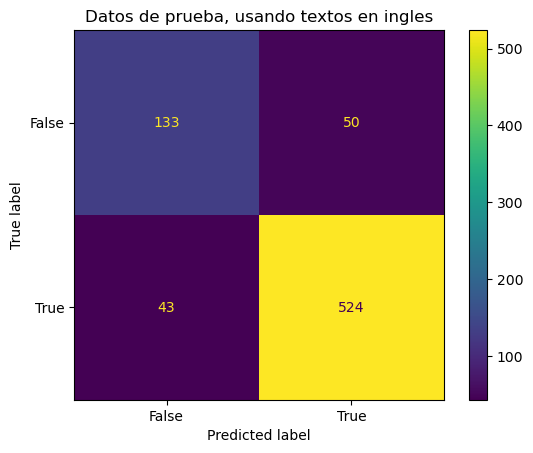

In [ ]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(test_df['act_label'],test_df['tuned_pred_en'])

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True],)

cm_display.plot();
cm_display.ax_.set_title("Datos de prueba, usando textos en ingles");

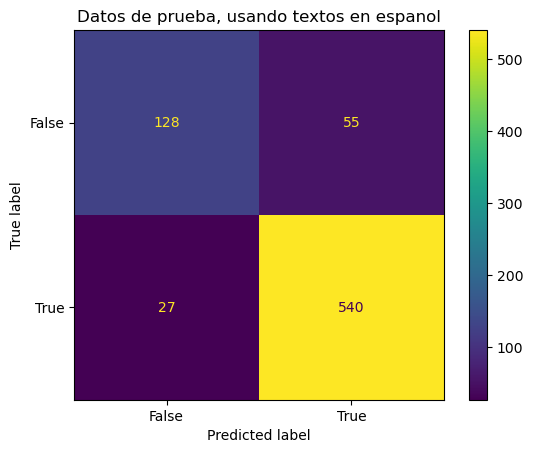

In [ ]:
confusion_matrix = metrics.confusion_matrix(test_df['act_label'],test_df['tuned_pred_es'])

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True],)

cm_display.plot();
cm_display.ax_.set_title("Datos de prueba, usando textos en espanol");

##COMENTARIOS FINALES

Los textos generados de manera directa obtienen desempeños menores que los textos de los modelos entrenados.
Una vez entrenados los modelos, tanto el de inglés como el de español arrojan desempeños muy favorables arriba del 90%.

Al realizar la predicción con modelos directos, no se obtiene buen resultado y es necesario utilizar un modelo entrenado para obtener un accuracy adecuado.

Como conclusión creemos necesario utilizar un modelo transformer entrenado con el idioma requerido para los textos de entrada.

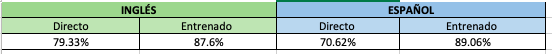